In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path resolution
def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(10):
        if (cur / "DATA" / "processed" / "master_df.parquet").exists():
            return cur
        if (cur / ".git").exists():
            return cur
        cur = cur.parent
    raise RuntimeError("Could not find repo root")

project_root = find_repo_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.regimes.hmm import (
    fit_hmm_models, 
    select_best_model, 
    extract_regime_labels,
    interpret_states,
    compute_regime_persistence
)

RESULTS_DIR = project_root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# print(f"Project root: {project_root}")

## Hidden Markov Model (HMM) Regime Estimation

**Objective**: Fit a Hidden Markov Model to identify latent market regimes based on the features constructed in notebook 09.

**HMM Use Case**
- **Regime switching**: Markets transition between distinct states (calm vs crisis, risk-on vs risk-off)
- **Latent states**: Regimes are not directly observable but inferred from feature dynamics
- **Probabilistic framework**: Captures uncertainty in regime classification vs hard thresholds
- **Temporal persistence**: Transition matrix captures regime stickiness and switching patterns

**Approach**:
1. Load stationary regime features (MOVE changes, DXY changes, macro surprise, curve signal)
2. Fit HMM models with 2, 3, 4 states using full covariance Gaussian emissions
3. Select optimal number of states using Bayesian Information Criterion (BIC)
4. Extract filtered regime probabilities and most likely state sequence (Viterbi algorithm)
5. Interpret regime states by computing mean feature values per state
6. Validate regimes against known crisis periods

**Data**: Features from [results/regime_features.csv](../results/regime_features.csv) (2005-2025, daily frequency after dropping NaNs)

In [2]:
# Load features from previous notebook
regime_features = pd.read_csv(RESULTS_DIR / "regime_features.csv", index_col=0, parse_dates=True).sort_index()
regime_features = regime_features.dropna()

### Fit HMM Models for 2, 3, 4 States

**Purpose**: Train multiple HMM models and compare their fit to determine optimal regime count.

**Model Specification**:
- **States**: 2, 3, 4 (testing parsimony vs granularity)
- **Covariance type**: Full (allows correlated feature dynamics within each regime)
- **Iterations**: 200 (sufficient for convergence with Baum-Welch EM algorithm)
- **Random seed**: 42 (reproducibility)

**What the HMM learns**:
- **Emission parameters**: Mean and covariance of features in each regime state
- **Transition matrix**: Probabilities of switching from state $i$ to state $j$
- **Initial state distribution**: Prior probability of starting in each regime

**Expected outcomes**:
- Convergence to local optimum (EM algorithm)
- BIC penalty discourages overfitting (more states = higher penalty)

In [3]:
# Fit HMM models for 2, 3, 4 states
models = fit_hmm_models(
    regime_features,
    n_states_range=[2,3,4],
    covariance_type='full',
    n_iter=200,
    random_state=42
)

### Model Selection with BIC

**Purpose**: Select the optimal number of regime states using Bayesian Information Criterion.

**BIC Formula**: 
$$\text{BIC} = -2 \log L + k \log n$$
where:
- $L$ = likelihood of the data given the model
- $k$ = number of free parameters
- $n$ = number of observations

**Interpretation**:
- Lower BIC = better model (balances fit quality and complexity)
- BIC penalizes excessive parameterization more heavily than AIC
- For HMM: More states → better fit but more parameters → higher penalty

**Decision rule**: Choose model with **minimum BIC**

**How to check**:
- BIC should decrease from 2 to 3 states (more states needed)
- BIC should increase from 3 to 4 states (overfitting) → 3 states optimal
- If BIC monotonically decreases, consider testing more states

In [4]:
# Model selection with BIC
best_model, best_n_states, bic_comparison = select_best_model(models, regime_features)

print("\n---BIC COMPARISON---")
print(bic_comparison)
print(f"\nOptimal model: {best_n_states} states (lowest BIC)")


---BIC COMPARISON---
   n_states  log_likelihood           bic
2         4   -32611.066209  65799.188255
1         3   -33930.123856  68267.581243
0         2   -36171.708069  72597.999595

Optimal model: 4 states (lowest BIC)


### Extract Regime Probabilities and Most Likely Path

**Purpose**: Decode the optimal regime sequence and compute filtered state probabilities.

**Algorithms used**:
- **Viterbi algorithm**: Finds the single most likely sequence of hidden states (regime_most_likely)
- **Forward algorithm**: Computes filtered probabilities $P(\text{State}_t | \text{Data}_{1:t})$ for each state at each time

**Output**:
- `regime_most_likely`: Discrete state assignments (0, 1, 2 for 3-state model)
- `regime_prob_0`, `regime_prob_1`, `regime_prob_2`: Probabilistic state memberships

**Significance**:
- Filtered probabilities capture regime uncertainty (smooth transitions)
- Most likely path provides clean regime labels for backtesting
- Probabilities sum to 1 at each time step

**Validation**: No missing values (regime assignment for every day in sample)

In [5]:
# Extract probabilities and most likely path
regime_labels = extract_regime_labels(best_model, regime_features)

print(f"\nRegime labels: {regime_labels.shape}")
print(regime_labels.head())

# Check for missing values
assert regime_labels.isna().sum().sum() == 0, "NaNs detected in regime labels"
print("\nNo missing values in regime probabilities")


Regime labels: (4847, 5)
            regime_prob_0  regime_prob_1  regime_prob_2  regime_prob_3  \
date                                                                     
2005-01-06       1.000000  4.467466e-264  1.412143e-225   2.670308e-84   
2005-01-07       0.999808   6.585954e-06   1.175136e-05   1.735417e-04   
2005-01-10       0.998300   1.286165e-04   2.259776e-05   1.548592e-03   
2005-01-11       0.916110   1.326918e-06   1.917987e-06   8.388699e-02   
2005-01-12       0.998109   1.577411e-05   1.012051e-04   1.773636e-03   

            regime_most_likely  
date                            
2005-01-06                   0  
2005-01-07                   0  
2005-01-10                   0  
2005-01-11                   0  
2005-01-12                   0  

No missing values in regime probabilities


### Regime State Interpretation

**Purpose**: Characterize each regime by computing mean feature values and assigning economic labels.

**Methodology**:
- For each state, compute average of each feature across all days assigned to that state
- Compare feature signatures across states to distinguish regimes
- Assign economic labels based on feature patterns

**Expected patterns**:
- **High MOVE, high DXY**: Crisis/stress regime (safe-haven USD demand, volatility spike)
- **Low MOVE, positive curve signal**: Reflation regime (curve steepening, low volatility)
- **Negative macro surprise**: Growth slowdown regime (synchronized disappointments)

**Bar chart significance**: Shows regime "fingerprints" — how each state differs on observable features

**How to check**:
- States should be economically interpretable (not arbitrary clusters)
- Feature values should differ meaningfully across states (separation)


---REGIME STATE SUMMARY---
                                              0                      1  \
state                                         0                      1   
move_chg                              -0.088447              -0.028653   
dxy_chg                                0.004402               0.005234   
curve_signal                          -0.009633              -0.092405   
macro_surprise                         0.190752              -1.664749   
n_days                                     1456                   1537   
pct_days                                30.0392              31.710336   
move_chg_zscore                       -0.503076               -0.31413   
dxy_chg_zscore                         0.453736               0.478801   
curve_signal_zscore                     -0.3617              -0.750946   
macro_surprise_zscore                  0.168552              -1.194498   
economic_label         Low Volatility / Risk-On  Slowdown / Flattening   

         

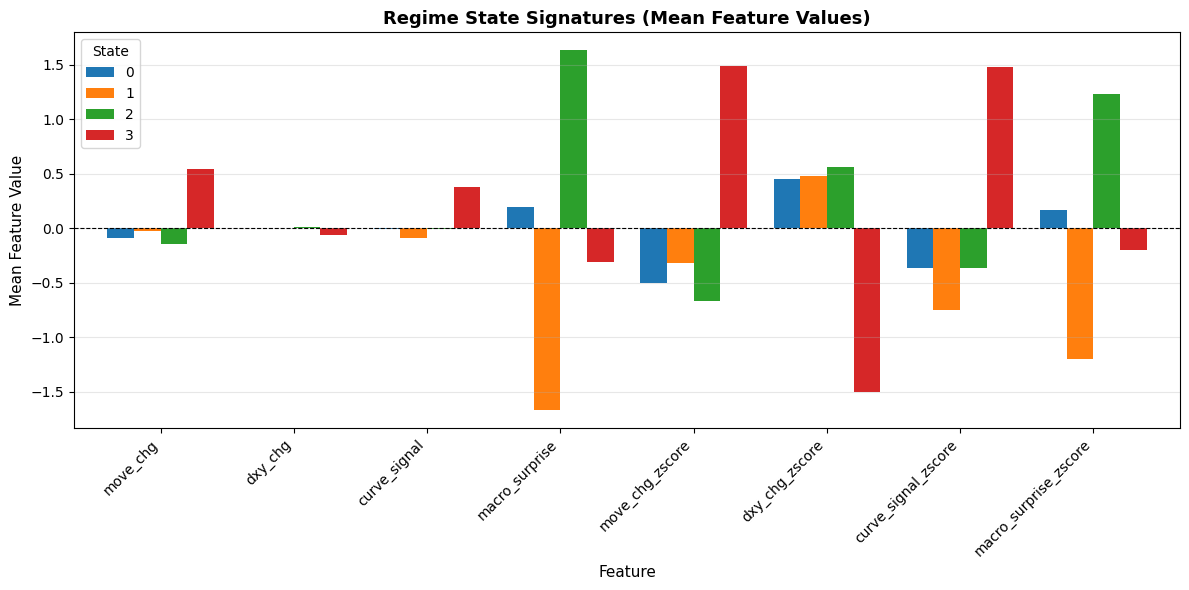

In [6]:
# Compute mean feature values per state
state_summary = interpret_states(best_model, regime_features, regime_labels)

print("\n---REGIME STATE SUMMARY---")
print(state_summary.T)

# Visualize state characteristics
fig, ax = plt.subplots(figsize=(12, 6))

feature_cols = [c for c in state_summary.columns if c not in ['state', 'n_days', 'pct_days', 'economic_label']]
state_summary_plot = state_summary[['state'] + feature_cols].set_index('state')

state_summary_plot.T.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean Feature Value', fontsize=11)
ax.set_xlabel('Feature', fontsize=11)
ax.set_title('Regime State Signatures (Mean Feature Values)', fontsize=13, fontweight='bold')
ax.legend(title='State', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Regime Persistence Analysis

**Purpose**: Validate that regimes persist long enough to be economically meaningful.

**Metrics**:
- **Mean duration**: Average length of a regime spell (days)
- **Min/Max duration**: Shortest and longest observed regime periods
- **Number of spells**: How many times each regime occurred

**Significance**:
- **High persistence (>1 week avg)**: Regimes reflect genuine macro shifts, not noise
- **Low persistence (<5 days avg)**: Regimes may be high-frequency noise, not useful for positioning
- **Extreme values**: Very short spells (1-2 days) suggest unstable regime estimates

**Relation to trading**:
- Minimum spell duration determines rebalancing frequency
- High-frequency regime switches → high transaction costs
- Persistent regimes → stable positioning signals

**How to check**: Average duration should be >5 days (1 week minimum for economic relevance)

In [7]:
# Compute persistence metrics
persistence = compute_regime_persistence(regime_labels)

print("\n--- REGIME PERSISTENCE ---")
print(persistence)

# Check minimum persistence
min_duration = persistence['min_duration_days'].min()
avg_duration = persistence['avg_duration_days'].mean()

print(f"\nAverage regime duration: {avg_duration:.1f} days")
print(f"Minimum regime spell: {min_duration:.0f} days")

if avg_duration > 5:
    print("\nRegimes persist long enough to be economically meaningful (>1 week typical)")
else:
    print("\nRegimes may be too fleeting (high-frequency noise)")


--- REGIME PERSISTENCE ---
   state  avg_duration_days  min_duration_days  max_duration_days  n_spells
0      0          19.675676                  3                 60        74
1      1          34.931818                  4                149        44
2      2          28.113208                  3                112        53
3      3           4.607595                  1                 67        79

Average regime duration: 21.8 days
Minimum regime spell: 1 days

Regimes persist long enough to be economically meaningful (>1 week typical)


In [8]:
state_summary

,state,move_chg,dxy_chg,curve_signal,macro_surprise,n_days,pct_days,move_chg_zscore,dxy_chg_zscore,curve_signal_zscore,macro_surprise_zscore,economic_label
0,0,-0.088447,0.004402,-0.009633,0.190752,1456,30.039200,-0.503076,0.453736,-0.361700,0.168552,Low Volatility / Risk-On
1,1,-0.028653,0.005234,-0.092405,-1.664749,1537,31.710336,-0.314130,0.478801,-0.750946,-1.194498,Slowdown / Flattening
2,2,-0.140358,0.008118,-0.009675,1.631037,1490,30.740664,-0.667112,0.565734,-0.361898,1.226585,Stable / Positive Surprises
3,3,0.540487,-0.060365,0.380841,-0.311823,364,7.509800,1.484318,-1.498272,1.474545,-0.200639,Crisis / Flight-to-Quality


### Regime Timeline Visualization

**Purpose**: Validate regime estimates against known macro events and assess alignment with volatility dynamics.

**Panels**:
1. **Top**: Regime state timeline (color-coded by most likely state)
2. **Bottom**: MOVE Index overlay (ground truth volatility measure)

**Validation checks**:
- Do high-volatility regimes align with MOVE spikes (GFC, COVID, tariff shock)?
- Do regime switches coincide with major macro events (policy shifts, crises)?
- Are calm regimes correctly identified during stable periods (2017-2019)?

**Crisis period overlays**:
- **GFC (Sep 2008 - Mar 2009)**: Should activate crisis regime
- **COVID (Feb-May 2020)**: Extreme volatility, should map to stress state
- **Fed Hike Uncertainty (Mar 2023)**: SVB collapse, regional bank stress
- **Trump Tariffs (Mar-May 2025)**: Trade war escalation

**Expected outcome**: Regime switches should anticipate or coincide with MOVE volatility breakouts

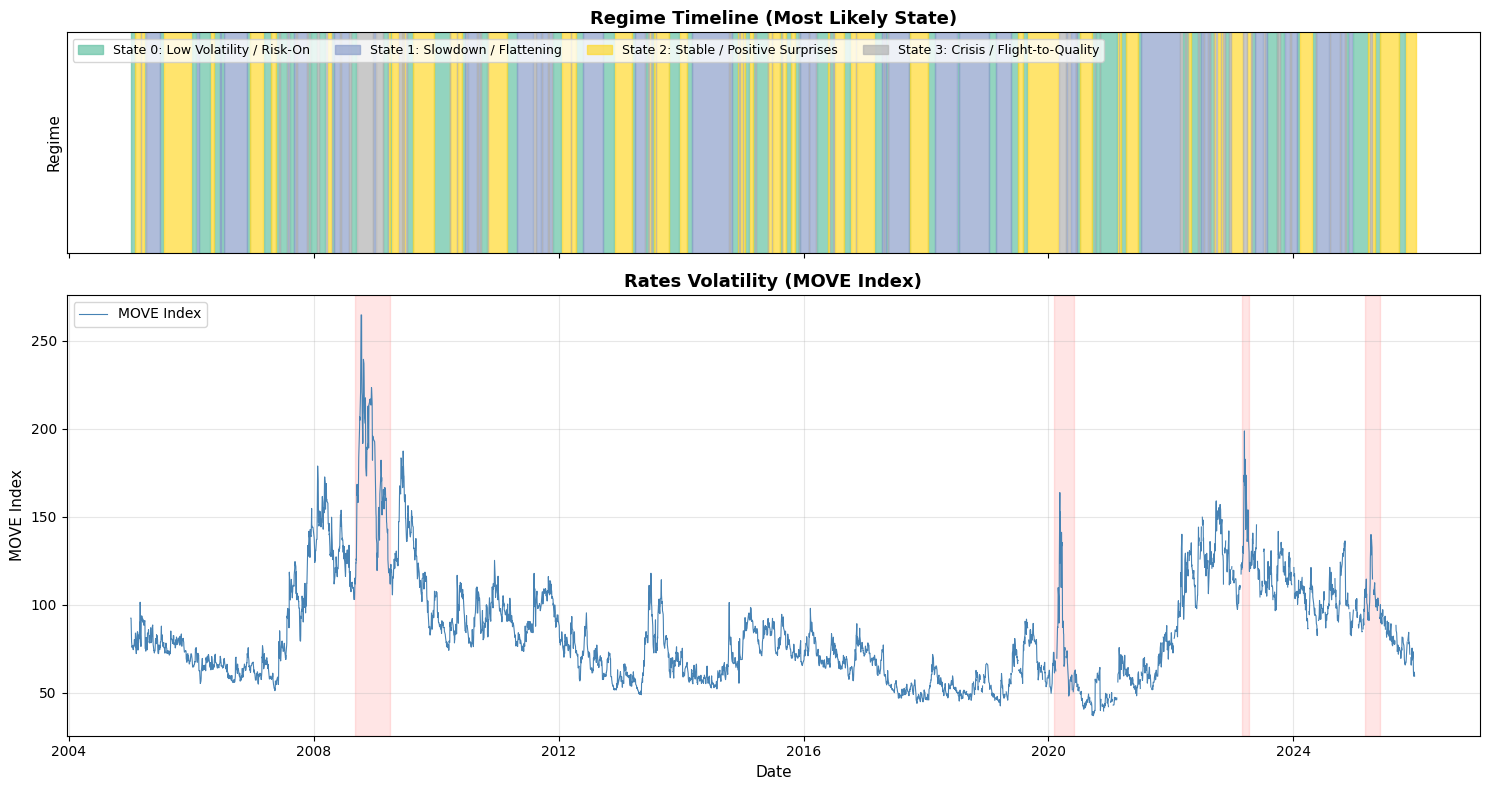

In [9]:
# Plot regime timeline with MOVE overlay
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, 
                         gridspec_kw={'height_ratios': [1, 2]})

# Top panel: Most likely regime state
regime_colors = plt.cm.Set2(np.linspace(0, 1, best_n_states))

for state in range(best_n_states):
    mask = regime_labels['regime_most_likely'] == state
    axes[0].fill_between(
        regime_labels.index, 0, 1, where=mask, 
        color=regime_colors[state], alpha=0.7, 
        label=f"State {state}: {state_summary.loc[state, 'economic_label']}"
    )

axes[0].set_ylabel('Regime', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].set_yticks([])
axes[0].legend(loc='upper left', fontsize=9, ncol=best_n_states)
axes[0].set_title('Regime Timeline (Most Likely State)', fontsize=13, fontweight='bold')

# Bottom panel: MOVE index for validation
# Load original MOVE for overlay
df_raw = pd.read_parquet(project_root / "DATA" / "processed" / "master_df.parquet")
move_series = df_raw['move__MOVE Index'].loc[regime_labels.index]

axes[1].plot(move_series.index, move_series, linewidth=0.8, color='steelblue', label='MOVE Index')
axes[1].set_ylabel('MOVE Index', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_title('Rates Volatility (MOVE Index)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', fontsize=10)

# Notable crisis periods
crisis_periods = [
    ('2008-09-01', '2009-03-31', 'GFC'),
    ('2020-02-01', '2020-05-31', 'COVID'),
    ('2023-03-01', '2023-04-10', 'Fed Hikes Uncertainty'),
    ('2025-03-01', '2025-05-31', 'Trump Tariffs')
]

for start, end, label in crisis_periods:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color='red')

plt.tight_layout()
plt.show()

### Filtered State Probabilities (Heatmap)

**Purpose**: Visualize regime uncertainty and gradual transitions over time.

**Interpretation**:
- **Bright red**: High probability (P > 0.8) — model is confident in this regime
- **Light yellow**: Low probability (P < 0.3) — regime unlikely
- **Mixed colors at same time**: Regime uncertainty (transition period)

**Why visualize probabilities vs just most likely state?**
- Captures transition periods where market is between regimes
- Shows model confidence (some periods have ambiguous regime membership)
- Smooth gradients indicate gradual regime shifts vs sudden breaks

**How to check**:
- Each column (time point) should have one dominant color (one state has P > 0.5)
- Transition zones should show gradual color shift, not instant flip
- Downsampling (every 5th day) improves readability for long time series

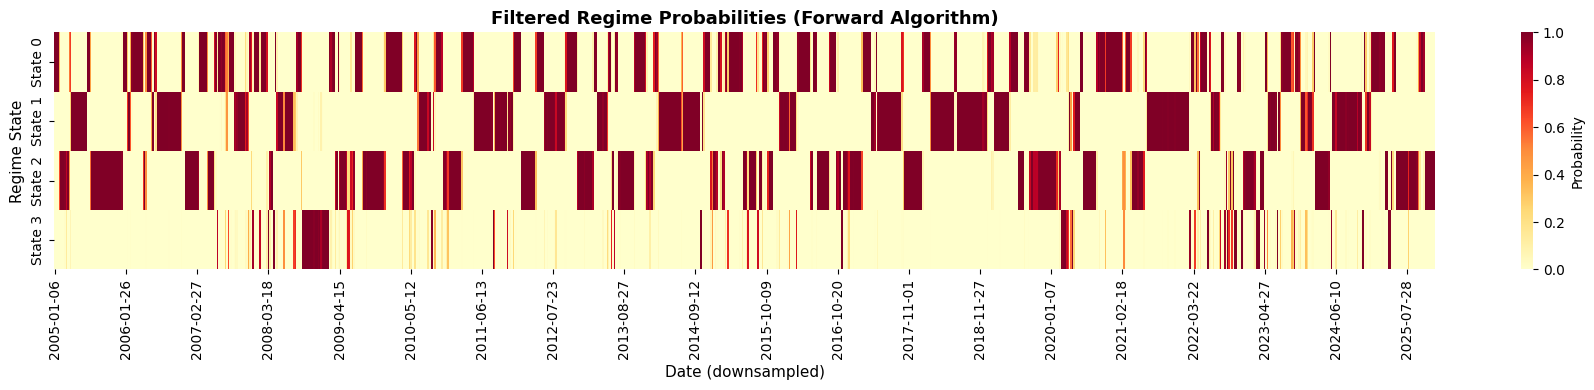

In [10]:
# Plot filtered state probabilities
prob_cols = [c for c in regime_labels.columns if 'regime_prob_' in c]
probs = regime_labels[prob_cols]

fig, ax = plt.subplots(figsize=(18, 4))

# Transpose for heatmap (states as rows, time as columns)
probs_1 = probs
probs_1.index = probs_1.index.strftime("%Y-%m-%d")
probs_T = probs_1.T

# Downsample for visualization (show every 5th day)
probs_plot = probs_T.iloc[:, ::5]

sns.heatmap(probs_plot, cmap='YlOrRd', cbar_kws={'label': 'Probability'}, 
            xticklabels=50, yticklabels=[f"State {i}" for i in range(best_n_states)],
            ax=ax)

ax.set_xlabel('Date (downsampled)', fontsize=11)
ax.set_ylabel('Regime State', fontsize=11)
ax.set_title('Filtered Regime Probabilities (Forward Algorithm)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Transition Matrix Analysis

**Purpose**: Understand regime dynamics — how likely is each regime to persist or switch?

**Matrix structure**: 
$$P_{ij} = P(\text{State}_t = j \mid \text{State}_{t-1} = i)$$
- Rows = current state
- Columns = next state
- Each row sums to 1 (transition probabilities)

**Diagonal elements (persistence)**:
- $P_{ii}$ = probability of staying in state $i$
- High diagonal (>0.9) = sticky regimes (long spells)
- Low diagonal (<0.7) = volatile regimes (frequent switches)

**Off-diagonal elements (switching)**:
- Asymmetric transitions (e.g., crisis → calm common, calm → crisis rare)
- Zero entries = forbidden transitions (structural constraints)

**Economic interpretation**:
- Crisis regimes should have lower persistence (markets heal)
- Calm regimes should have high persistence (stable equilibria)
- Sudden transitions indicate structural breaks

**How to check**: Average diagonal should be 0.7-0.9 (moderate persistence, realistic dynamics)


---TRANSITION MATRIX---
          State 0        State 1        State 2   State 3
State 0  0.944199   1.420970e-02   1.982466e-02  0.021766
State 1  0.011328   9.663322e-01  1.602854e-111  0.022340
State 2  0.020200  5.268854e-107   9.594257e-01  0.020375
State 3  0.085611   7.808972e-02   8.045187e-02  0.755848


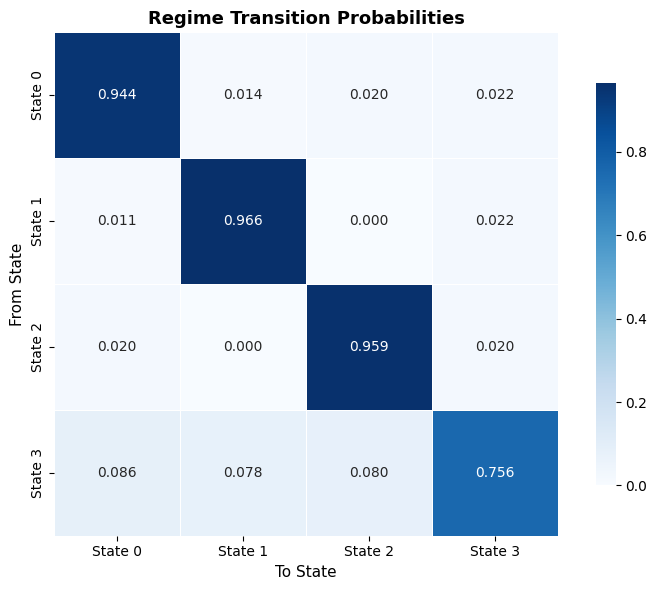


Average diagonal (persistence): 0.906
High persistence (regimes stick)


In [11]:
# Extract and visualize transition matrix
transition_matrix = pd.DataFrame(
    best_model.transmat_,
    index=[f"State {i}" for i in range(best_n_states)],
    columns=[f"State {i}" for i in range(best_n_states)]
)

print("\n---TRANSITION MATRIX---")
print(transition_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='Blues', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_xlabel('To State', fontsize=11)
ax.set_ylabel('From State', fontsize=11)
ax.set_title('Regime Transition Probabilities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Check diagonal dominance (persistence)
diag_mean = np.diag(transition_matrix).mean()
print(f"\nAverage diagonal (persistence): {diag_mean:.3f}")

if diag_mean > 0.9:
    print("High persistence (regimes stick)")
elif diag_mean > 0.7:
    print("Moderate persistence (realistic regime dynamics)")
else:
    print("️Low persistence (regimes may be too volatile)")

### Crisis Period Regime Validation

**Purpose**: Verify that the HMM correctly identifies known crisis periods.

**Methodology**:
- For each crisis window, find the dominant regime (modal state)
- Compute % of days in crisis period assigned to that regime
- Compare economic label to actual crisis characteristics

**Expected mappings**:
- **GFC (2008-09)**: Should map to high-stress/crisis regime
- **COVID (2020)**: Should map to extreme volatility regime
- **Fed Hike Uncertainty (2023)**: Should map to tightening/stress regime
- **Trump Tariffs (2025)**: Should map to policy uncertainty/risk-off regime

**Red flags**:
- Crisis period mapped to "calm" regime → model failure
- Low % in dominant regime (<50%) → ambiguous regime during crisis
- Same regime for all crises → insufficient regime granularity

**How to check**: Each crisis should have >70% of days in appropriate stress/volatility regime

In [12]:
# Check which regimes dominated during known crises
crisis_mapping = {
    'GFC (2008-09)': ('2008-09-01', '2009-03-31'),
    'COVID (2020-Q1)': ('2020-02-01', '2020-05-31'),
    'Fed Hike Uncertainty (2023)': ('2023-03-01', '2023-04-10'),
    'Trump Tariffs (2025)': ('2025-03-01', '2025-05-31')
}

print("\n---CRISIS PERIOD REGIME MAPPING---")

for crisis_name, (start, end) in crisis_mapping.items():
    mask = (regime_labels.index >= start) & (regime_labels.index <= end)
    crisis_regimes = regime_labels.loc[mask, 'regime_most_likely']
    
    if len(crisis_regimes) > 0:
        mode_regime = crisis_regimes.mode()[0]
        pct_in_mode = (crisis_regimes == mode_regime).sum() / len(crisis_regimes) * 100
        
        print(f"\n{crisis_name}:")
        print(f"  Dominant regime: State {mode_regime} ({pct_in_mode:.1f}% of days)")
        print(f"  Label: {state_summary.loc[mode_regime, 'economic_label']}")
    else:
        print(f"\n{crisis_name}: No data in this period")


---CRISIS PERIOD REGIME MAPPING---

GFC (2008-09):
  Dominant regime: State 3 (70.2% of days)
  Label: Crisis / Flight-to-Quality

COVID (2020-Q1):
  Dominant regime: State 3 (54.7% of days)
  Label: Crisis / Flight-to-Quality

Fed Hike Uncertainty (2023):
  Dominant regime: State 3 (57.1% of days)
  Label: Crisis / Flight-to-Quality

Trump Tariffs (2025):
  Dominant regime: State 0 (55.6% of days)
  Label: Low Volatility / Risk-On


In [13]:
# Save regime probabilities
regime_probs_path = RESULTS_DIR / "regime_probabilities.csv"
regime_labels.to_csv(regime_probs_path)
# print(f"\nSaved: {regime_probs_path}")

# Save state summary
state_summary_path = RESULTS_DIR / "regime_state_summary.csv"
state_summary.to_csv(state_summary_path, index=False)
# print(f"Saved: {state_summary_path}")

# Save BIC comparison
bic_path = RESULTS_DIR / "regime_model_selection_bic.csv"
bic_comparison.to_csv(bic_path, index=False)
# print(f"Saved: {bic_path}")

# Save transition matrix
transition_path = RESULTS_DIR / "regime_transition_matrix.csv"
transition_matrix.to_csv(transition_path)
# print(f"Saved: {transition_path}")

# Save persistence metrics
persistence_path = RESULTS_DIR / "regime_persistence.csv"
persistence.to_csv(persistence_path, index=False)
# print(f"Saved: {persistence_path}")

### Extract Regime Intervals (Date Ranges)

**Purpose**: Convert discrete regime labels into explicit date ranges for each regime spell.

**Output format**:
- `state`: Regime identifier (0, 1, 2, 3)
- `start_date`: First day of regime spell
- `end_date`: Last day of regime spell
- `duration_days`: Length of regime period

**Use cases**:
1. **Strategy conditioning**: Apply different trading rules in different regimes
2. **Backtest segmentation**: Evaluate strategy performance per regime
3. **Risk management**: Adjust position sizes based on current regime
4. **Interpretability**: Easy lookup of "when was regime X active?"

**Summary statistics**:
- Total number of regime switches
- Longest spell per regime (validates persistence)
- Example periods (links regimes to calendar events)

**How to check**: Number of switches should be <100 (not too noisy), >10 (not too static)

In [14]:
def extract_regime_intervals(regime_labels: pd.DataFrame) -> pd.DataFrame:
    """
    Extract date intervals for each regime state.
    
    :param regime_labels: DataFrame with 'regime_most_likely' column and DatetimeIndex
    :return: DataFrame with columns: state, start_date, end_date, duration_days
    """
    regime_seq = regime_labels['regime_most_likely'].values
    dates = regime_labels.index
    
    # Find regime switches
    switches = np.where(np.diff(regime_seq) != 0)[0] + 1
    switches = np.concatenate([[0], switches, [len(regime_seq)]])
    
    intervals = []
    
    for i in range(len(switches) - 1):
        start_idx = switches[i]
        end_idx = switches[i + 1] - 1  # Last day of this regime
        
        state = regime_seq[start_idx]
        start_date = dates[start_idx]
        end_date = dates[end_idx]
        duration = (end_date - start_date).days + 1  # +1 to include both endpoints
        
        intervals.append({
            'state': state,
            'start_date': start_date,
            'end_date': end_date,
            'duration_days': duration
        })
    
    return pd.DataFrame(intervals)


# Usage in notebook - add this cell after your regime extraction
regime_intervals = extract_regime_intervals(regime_labels)

print("\n--- REGIME INTERVALS ---")
print(f"Total regime switches: {len(regime_intervals)}")
print(f"\nFirst 5 intervals:")
print(regime_intervals.head(5))

# Save to CSV
intervals_path = RESULTS_DIR / "regime_intervals.csv"
regime_intervals.to_csv(intervals_path, index=False)
print(f"\nSaved: {intervals_path}")

# Summary by state
print("\n--- INTERVALS PER STATE ---")
for state in sorted(regime_intervals['state'].unique()):
    state_intervals = regime_intervals[regime_intervals['state'] == state]
    print(f"\nState {state}: {len(state_intervals)} spells")
    print(f"  Longest spell: {state_intervals['duration_days'].max()} days")
    print(f"  Example periods:")
    print(state_intervals.nlargest(3, 'duration_days')[['start_date', 'end_date', 'duration_days']].to_string(index=False))


--- REGIME INTERVALS ---
Total regime switches: 250

First 5 intervals:
   state start_date   end_date  duration_days
0      0 2005-01-06 2005-01-28             23
1      2 2005-01-31 2005-03-04             33
2      3 2005-03-07 2005-03-07              1
3      2 2005-03-08 2005-03-25             18
4      0 2005-03-30 2005-04-01              3

Saved: /Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/results/regime_intervals.csv

--- INTERVALS PER STATE ---

State 0: 74 spells
  Longest spell: 102 days
  Example periods:
start_date   end_date  duration_days
2020-11-06 2021-02-15            102
2009-12-21 2010-03-24             94
2024-12-19 2025-03-20             92

State 1: 44 spells
  Longest spell: 232 days
  Example periods:
start_date   end_date  duration_days
2021-07-08 2022-02-24            232
2014-03-06 2014-10-15            224
2018-07-19 2019-01-09            175

State 2: 53 spells
  Longest spell: 183 days
  Example periods:
start_date 